In [ ]:
import torch
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),                        
    transforms.Normalize((0.1307,), (0.3081,))      
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',      
    train=True,           
    transform=transform,   
    download=True          
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True,       
    num_workers=2
)

# 验证：查看一个 batch 的形状
images, labels = next(iter(train_loader))
print(f"图像 batch 形状: {images.shape}")   
print(f"标签 batch 形状: {labels.shape}")    # [64]
print(f"像素值范围: [{images.min():.3f}, {images.max():.3f}]")   # 归一化后约为 [-0.42, 2.82]

# 可视化前 8 张图
fig, axes = plt.subplots(1, 8, figsize=(12, 3))
for i in range(8):
    img = images[i].squeeze(0)  
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"标签: {labels[i].item()}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import model
import torch.optim as optim
import numpy as np

T = 1000
Model = model.Diffusion(T).to(device)
optimizer = optim.Adam(Model.parameters(), lr=0.001, weight_decay=1e-4)

# train
num_epochs = 50
for epochs in range(num_epochs):
    print(epochs)
    for images, labels in train_loader:
        images = images.to(device)
        t = np.random.randint(1, T, size=images.shape[0])
        t = torch.tensor(t, device=device)
        Loss = Model(images, t)
        
        optimizer.zero_grad()
        Loss.backward()
        optimizer.step()

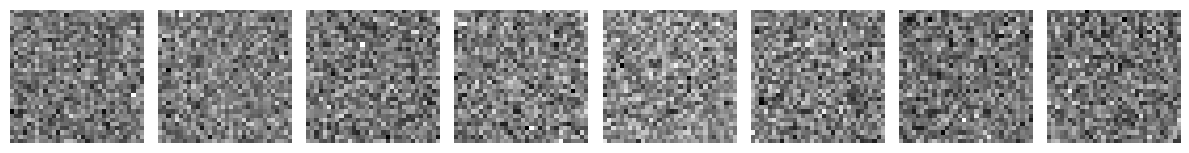

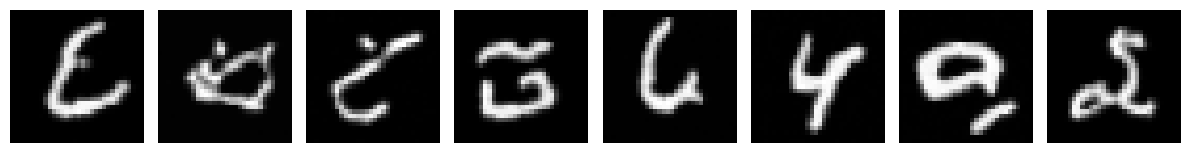

In [4]:
# eval
X = torch.randn([64, 1, 32, 32], device=device)

X_cpu = X.cpu()
fig, axes = plt.subplots(1, 8, figsize=(12, 3))
for i in range(8):
    img = X_cpu[i].squeeze(0)  
    img_vis=img * 0.3081 + 0.1307
    axes[i].imshow(img_vis, cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

with torch.no_grad(): # 测试要加上，不然建立巨大计算图
    for i in range(T - 1, 0, -1):
        t = torch.full((64,), i, device=device)
        X = Model.step(X, t)

# 将结果移回 CPU 用于绘图
X_cpu = X.cpu()
fig, axes = plt.subplots(1, 8, figsize=(12, 3))
for i in range(8):
    img = X_cpu[i].squeeze(0)  
    img_vis=img * 0.3081 + 0.1307
    axes[i].imshow(img_vis, cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()